<a href="https://colab.research.google.com/github/giovanis11/BigData/blob/main/ITC4441_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============ CELL 1: Setup & Imports ============
from google.colab import drive
drive.mount('/content/drive')

import os, json, warnings, gc, random
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
random.seed(42)

base_path = '/content/drive/MyDrive/ITC441-Project'
tweets_path = base_path + '/snow14_testset_tweets'
output_path = base_path + '/'

print("All imports successful")

Mounted at /content/drive
All imports successful


In [ ]:
# ============ CELL 2: Load Data ============
all_tweets = []
available_files = sorted(os.listdir(tweets_path))[:3]
print(f"Loading {len(available_files)} files: {available_files}")

for filename in available_files:
    filepath = tweets_path + '/' + filename
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                all_tweets.append(json.loads(line))
            except:
                continue

print(f"Total tweets loaded: {len(all_tweets)}")

Loading 3 files: ['tweets.json.0', 'tweets.json.1', 'tweets.json.10']
Total tweets loaded: 76989


In [ ]:
# ============ CELL 3: Build Directed User-to-User Network ============
G = nx.DiGraph()
user_tweets = defaultdict(list)

for tweet in all_tweets:
    try:
        source = tweet['user']['screen_name']
        user_tweets[source].append(tweet['text'])

        # Retweet edge
        if tweet.get('retweeted_status') and tweet['retweeted_status'] is not None:
            target = tweet['retweeted_status']['user']['screen_name']
            if source != target:
                if G.has_edge(source, target):
                    G[source][target]['weight'] += 1
                else:
                    G.add_edge(source, target, weight=1, edge_type='retweet')

        # Reply edge
        if tweet.get('in_reply_to_screen_name') and tweet['in_reply_to_screen_name'] is not None:
            target = tweet['in_reply_to_screen_name']
            if source != target:
                if G.has_edge(source, target):
                    G[source][target]['weight'] += 1
                else:
                    G.add_edge(source, target, weight=1, edge_type='reply')

        # Mention edges
        for mention in tweet['entities'].get('user_mentions', []):
            target = mention['screen_name']
            if source != target:
                if G.has_edge(source, target):
                    G[source][target]['weight'] += 1
                else:
                    G.add_edge(source, target, weight=1, edge_type='mention')
    except:
        continue

# Free raw tweets from memory
del all_tweets
gc.collect()

print(f"Network built successfully")
print(f"Nodes (users): {G.number_of_nodes()}")
print(f"Edges (connections): {G.number_of_edges()}")

# Save network file
nx.write_edgelist(G, output_path + 'network-Giovanis2026.data', data=['weight', 'edge_type'])
print("Saved: network-Giovanis2026.data")

Network built successfully
Nodes (users): 60184
Edges (connections): 80103
Saved: network-Giovanis2026.data


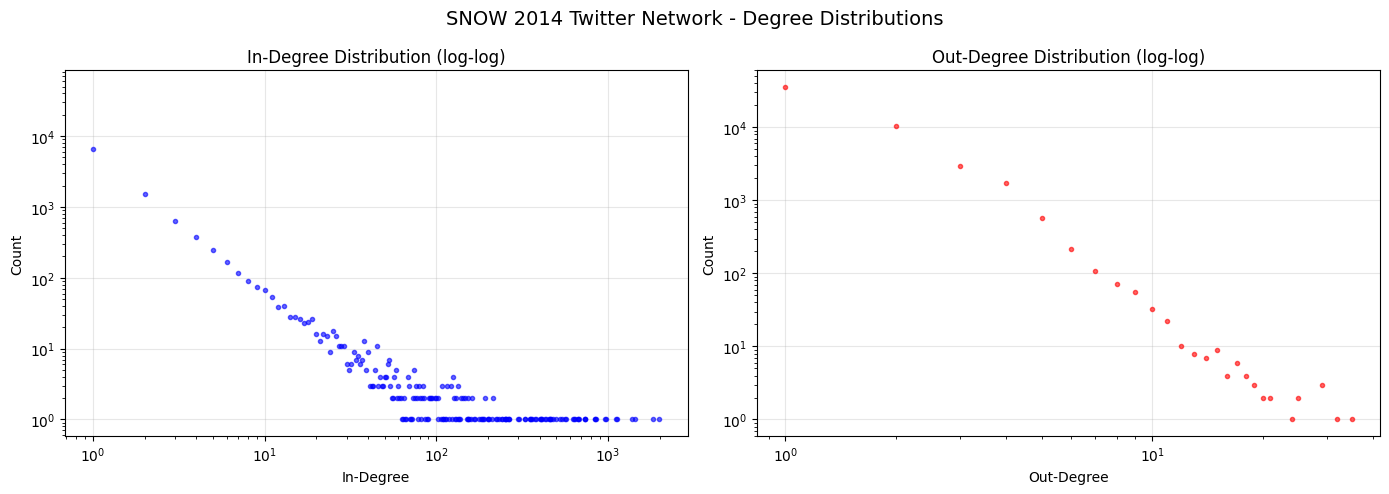

Max in-degree: 1988
Max out-degree: 35
Average in-degree: 1.331
Average out-degree: 1.331


In [ ]:
# ============ CELL 4: Power-Law Degree Distribution ============
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

in_counts = Counter(in_degrees)
in_x = sorted(in_counts.keys())
in_y = [in_counts[k] for k in in_x]
axes[0].loglog(in_x, in_y, 'bo', markersize=3, alpha=0.6)
axes[0].set_title('In-Degree Distribution (log-log)')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

out_counts = Counter(out_degrees)
out_x = sorted(out_counts.keys())
out_y = [out_counts[k] for k in out_x]
axes[1].loglog(out_x, out_y, 'ro', markersize=3, alpha=0.6)
axes[1].set_title('Out-Degree Distribution (log-log)')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.suptitle('SNOW 2014 Twitter Network - Degree Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(output_path + 'degree_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max in-degree: {max(in_degrees)}")
print(f"Max out-degree: {max(out_degrees)}")
print(f"Average in-degree: {np.mean(in_degrees):.3f}")
print(f"Average out-degree: {np.mean(out_degrees):.3f}")

In [ ]:
# ============ CELL 5: Centrality Measures ============
print("Computing degree centrality...")
degree_centrality_in = nx.in_degree_centrality(G)
degree_centrality_out = nx.out_degree_centrality(G)

print("Computing PageRank...")
pagerank = nx.pagerank(G, alpha=0.85, weight='weight')

print("Computing betweenness (approximation)...")
betweenness = nx.betweenness_centrality(G, k=500, normalized=True)

# Save degree.data
degree_df = pd.DataFrame({
    'screen_name': list(degree_centrality_in.keys()),
    'in_degree_centrality': [degree_centrality_in[u] for u in degree_centrality_in],
    'out_degree_centrality': [degree_centrality_out[u] for u in degree_centrality_in]
})
degree_df['total_degree_centrality'] = degree_df['in_degree_centrality'] + degree_df['out_degree_centrality']
degree_df = degree_df.sort_values('total_degree_centrality', ascending=False)
degree_df.to_csv(output_path + 'degree.data', index=False)
print("Saved: degree.data")

# Save pageRank.data
pagerank_df = pd.DataFrame({
    'screen_name': list(pagerank.keys()),
    'pagerank': list(pagerank.values())
}).sort_values('pagerank', ascending=False)
pagerank_df.to_csv(output_path + 'pageRank.data', index=False)
print("Saved: pageRank.data")

# Save betweeness.data
betweenness_df = pd.DataFrame({
    'screen_name': list(betweenness.keys()),
    'betweenness_centrality': list(betweenness.values())
}).sort_values('betweenness_centrality', ascending=False)
betweenness_df.to_csv(output_path + 'betweeness.data', index=False)
print("Saved: betweeness.data")

print("\nDone! All centrality files saved.")

Computing degree centrality...
Computing PageRank...
Computing betweenness (approximation)...
Saved: degree.data
Saved: pageRank.data
Saved: betweeness.data

Done! All centrality files saved.


In [ ]:
# ============ CELL 6: Top 10 User Characterization ============
top10_degree = degree_df.head(10)['screen_name'].tolist()
top10_pagerank = pagerank_df.head(10)['screen_name'].tolist()
top10_betweenness = betweenness_df.head(10)['screen_name'].tolist()

def characterize_user(screen_name, user_tweets, G):
    tweets = user_tweets.get(screen_name, [])
    if not tweets:
        in_deg = G.in_degree(screen_name)
        out_deg = G.out_degree(screen_name)
        return [f'high-influence account', f'in-degree:{in_deg}', f'out-degree:{out_deg}', 'not in sample']
    hashtags = []
    words = []
    for text in tweets:
        for word in text.split():
            if word.startswith('#'):
                hashtags.append(word.lower().strip('.,!?'))
            elif not word.startswith('@') and not word.startswith('http') and len(word) > 3:
                words.append(word.lower().strip('.,!?'))
    top_hashtags = [h for h, c in Counter(hashtags).most_common(3)]
    top_words = [w for w, c in Counter(words).most_common(3)]
    tags = top_hashtags + top_words
    return tags[:5] if tags else ['general discussion']

print("=" * 60)
print("TOP 10 - DEGREE CENTRALITY")
print("=" * 60)
for user in top10_degree:
    tags = characterize_user(user, user_tweets, G)
    print(f"@{user}: {tags}")

print("\n" + "=" * 60)
print("TOP 10 - PAGERANK")
print("=" * 60)
for user in top10_pagerank:
    tags = characterize_user(user, user_tweets, G)
    print(f"@{user}: {tags}")

print("\n" + "=" * 60)
print("TOP 10 - BETWEENNESS")
print("=" * 60)
for user in top10_betweenness:
    tags = characterize_user(user, user_tweets, G)
    print(f"@{user}: {tags}")

TOP 10 - DEGREE CENTRALITY
@rioferdy5: ['high-influence account', 'in-degree:1988', 'out-degree:0', 'not in sample']
@civicua: ['#venezuela', '#ukraine', 'strong', "don't", 'give']
@piersmorgan: ['#pompousb…', 'your', 'make-up', 'artist']
@jimmyfallon: ['#fallontonight', 'with', 'show', 'tonight']
@HuffingtonPost: ['#modernfamily', 'this', 'what', 'when']
@Persie_Official: ['high-influence account', 'in-degree:1120', 'out-degree:0', 'not in sample']
@WayneRooney: ['high-influence account', 'in-degree:975', 'out-degree:0', 'not in sample']
@NASA: ['live', 'now', 'listen']
@realDonaldTrump: ['aspiring', 'entrepreneurs:', 'your']
@SethMacFarlane: ['high-influence account', 'in-degree:841', 'out-degree:0', 'not in sample']

TOP 10 - PAGERANK
@civicua: ['#venezuela', '#ukraine', 'strong', "don't", 'give']
@sverdlychenko: ['#venezuela', '#ukraine', 'strong', "don't", 'give']
@piersmorgan: ['#pompousb…', 'your', 'make-up', 'artist']
@rioferdy5: ['high-influence account', 'in-degree:1988', 'ou

## Q2 - Community Detection
Applying the Louvain algorithm to detect communities in the user-user network. Louvain is chosen because it is efficient on large graphs, handles weighted edges, and automatically determines the optimal number of communities.

In [ ]:
# ============ CELL 7: Community Detection (Louvain) ============
!pip install python-louvain -q
import community as community_louvain

G_undirected = G.to_undirected()
print("Running Louvain community detection...")
partition = community_louvain.best_partition(G_undirected, weight='weight')

num_communities = len(set(partition.values()))
community_sizes = Counter(partition.values())
top_communities = [comm_id for comm_id, size in community_sizes.most_common(15)]

print(f"Total communities found: {num_communities}")
print(f"Communities with >100 users: {sum(1 for s in community_sizes.values() if s > 100)}")
print(f"Communities with <10 users: {sum(1 for s in community_sizes.values() if s < 10)}")
print(f"\nTop 15 communities cover: {sum(community_sizes[c] for c in top_communities)} users")
print(f"\nTop 10 largest communities:")
for comm_id, size in community_sizes.most_common(10):
    print(f"  Community {comm_id}: {size} users")

Running Louvain community detection...
Total communities found: 2580
Communities with >100 users: 91
Communities with <10 users: 2418

Top 15 communities cover: 21880 users

Top 10 largest communities:
  Community 37: 2718 users
  Community 18: 2530 users
  Community 8: 1709 users
  Community 6: 1688 users
  Community 33: 1661 users
  Community 121: 1566 users
  Community 12: 1438 users
  Community 133: 1419 users
  Community 4: 1110 users
  Community 29: 1062 users


In [ ]:
# ============ CELL 8: Save Communities File ============
community_records = []
for screen_name, comm_id in partition.items():
    community_records.append({
        'user_id': screen_name,
        'screen_name': screen_name,
        'community_id': comm_id
    })

communities_df = pd.DataFrame(community_records).drop_duplicates(subset='screen_name')
communities_df = communities_df.sort_values('community_id')
communities_df.to_csv(output_path + 'communities2025.data', index=False)
print(f"Saved communities2025.data with {len(communities_df)} users")
print(communities_df.head())

Saved communities2025.data with 60184 users
               user_id      screen_name  community_id
0         LovesickHank     LovesickHank             0
1        TimesBusiness    TimesBusiness             0
22882   LeaMalikLMixer   LeaMalikLMixer             1
17867        BHawker19        BHawker19             1
30042  pageswithnoends  pageswithnoends             1


In [ ]:
# ============ CELL 9: Dominant Hashtags & Keywords per Community ============
community_hashtags = defaultdict(list)
community_keywords = defaultdict(list)
top_community_set = set(top_communities)

for screen_name, texts in user_tweets.items():
    comm_id = partition.get(screen_name)
    if comm_id not in top_community_set:
        continue
    for text in texts:
        for word in text.split():
            if word.startswith('#'):
                community_hashtags[comm_id].append(word.lower().strip('.,!?'))
            elif not word.startswith('@') and not word.startswith('http') and len(word) > 4:
                community_keywords[comm_id].append(word.lower().strip('.,!?'))

print("Top hashtags and keywords per community:")
print("=" * 60)
for comm_id in top_communities[:10]:
    top_tags = [h for h, c in Counter(community_hashtags[comm_id]).most_common(5)]
    top_words = [w for w, c in Counter(community_keywords[comm_id]).most_common(5)]
    print(f"\nCommunity {comm_id} ({community_sizes[comm_id]} users)")
    print(f"  Hashtags: {top_tags}")
    print(f"  Keywords: {top_words}")

Top hashtags and keywords per community:

Community 37 (2718 users)
  Hashtags: ['#ukraine', '#venezuela', '#euromaidan', '#artforfreedom', '#vzlaelquesecansa…']
  Keywords: ['liubov', 'yeremicheva', 'photo', 'fight', '"@civicua:']

Community 18 (2530 users)
  Hashtags: ['#transferdeadlineday', '#mufc', '#cldraw', '#syria', '#tears4piers']
  Keywords: ['rough', 'week', 'having', 'thought', 'wow']

Community 8 (1709 users)
  Hashtags: ['#bitcoin', '#mwc14', '#mtgox', '#stitch', '#youprobablyshouldpanic']
  Keywords: ['internet', 'fucked', 'water', 'spent', 'bitcoin']

Community 6 (1688 users)
  Hashtags: ['#indigenous', '#biafrans', '#indigenouspeopleofbiafra', '#if', '#ukraine']
  Keywords: ['daily', 'children', 'would', 'mail', 'comes']

Community 33 (1661 users)
  Hashtags: ['#mufc', '#hope', '#transferdeadlineday', '#championsleague', '#olympiakos']
  Keywords: ['keane', 'moyes', 'united', 'done', 'still']

Community 121 (1566 users)
  Hashtags: ['#mufc', '#transferdeadlineday', '#c

In [ ]:
# ============ CELL 10: Save Community Summary ============
community_summary = []
for comm_id in top_communities:
    top_tags = [h for h, c in Counter(community_hashtags[comm_id]).most_common(5)]
    top_words = [w for w, c in Counter(community_keywords[comm_id]).most_common(5)]
    community_summary.append({
        'community_id': comm_id,
        'size': community_sizes[comm_id],
        'top_hashtags': ', '.join(top_tags),
        'top_keywords': ', '.join(top_words)
    })

summary_df = pd.DataFrame(community_summary)
summary_df.to_csv(output_path + 'community_summary.data', index=False)
print("Saved community_summary.data")
print(summary_df[['community_id', 'size', 'top_hashtags']].to_string())

Saved community_summary.data
    community_id  size                                                                top_hashtags
0             37  2718       #ukraine, #venezuela, #euromaidan, #artforfreedom, #vzlaelquesecansa…
1             18  2530                  #transferdeadlineday, #mufc, #cldraw, #syria, #tears4piers
2              8  1709                  #bitcoin, #mwc14, #mtgox, #stitch, #youprobablyshouldpanic
3              6  1688            #indigenous, #biafrans, #indigenouspeopleofbiafra, #if, #ukraine
4             33  1661           #mufc, #hope, #transferdeadlineday, #championsleague, #olympiakos
5            121  1566    #mufc, #transferdeadlineday, #championsleague, #olympiakos, #infographic
6             12  1438                                   #endfgm, #ukraine, #london, #syria, #iran
7            133  1419  #tonightbattle, #fallontonight, #swimmyfallon, #sosvenezuela, #polarplunge
8              4  1110                  #ukraine, #euromaidan, #russia, #cdnpoli

In [ ]:
# ============ CELL 11: Build User Feature Vectors ============
print("Computing network features...")
pagerank = nx.pagerank(G, alpha=0.85, weight='weight')
clustering = nx.clustering(G.to_undirected())

user_features = {}
for node in G.nodes():
    user_features[node] = {
        'in_degree': G.in_degree(node),
        'out_degree': G.out_degree(node),
        'pagerank': pagerank.get(node, 0),
        'clustering': clustering.get(node, 0),
        'community_id': partition.get(node, -1)
    }

print("Computing content features...")
all_hashtags = set()
for comm_id in top_communities:
    for h, c in Counter(community_hashtags[comm_id]).most_common(10):
        all_hashtags.add(h)
all_hashtags = list(all_hashtags)
print(f"Unique hashtags as features: {len(all_hashtags)}")

user_hashtag_vectors = defaultdict(lambda: defaultdict(int))
for screen_name, texts in user_tweets.items():
    for text in texts:
        for word in text.split():
            word = word.lower().strip('.,!?')
            if word in all_hashtags:
                user_hashtag_vectors[screen_name][word] += 1

print("Building final feature vectors...")
records = []
for node in G.nodes():
    feats = user_features[node]
    hashtag_vec = user_hashtag_vectors.get(node, {})
    row = {
        'user_id': node,
        'screen_name': node,
        'in_degree': feats['in_degree'],
        'out_degree': feats['out_degree'],
        'pagerank': feats['pagerank'],
        'clustering': feats['clustering'],
        'community_id': feats['community_id']
    }
    for h in all_hashtags:
        row[f'h_{h[1:]}'] = hashtag_vec.get(h, 0)
    records.append(row)

vectors_df = pd.DataFrame(records)
vectors_df.to_csv(output_path + 'user_vectors2025.data', index=False)
print(f"Saved user_vectors2025.data")
print(f"Shape: {vectors_df.shape}")

Computing network features...
Computing content features...
Unique hashtags as features: 108
Building final feature vectors...
Saved user_vectors2025.data
Shape: (60184, 115)


In [ ]:
# ============ CELL 12: Train ML Model ============
print("Preparing training data...")
edges = list(G.edges())
edge_set = set(edges)
nodes = list(G.nodes())

# Generate negative examples
negative_edges = []
while len(negative_edges) < len(edges):
    u = random.choice(nodes)
    v = random.choice(nodes)
    if u != v and (u, v) not in edge_set:
        negative_edges.append((u, v))

print(f"Positive examples: {len(edges)}")
print(f"Negative examples: {len(negative_edges)}")

feature_cols = ['in_degree', 'out_degree', 'pagerank', 'clustering', 'community_id']
vectors_indexed = vectors_df.set_index('screen_name')

def get_pair_features(u, v):
    try:
        fu = vectors_indexed.loc[u, feature_cols].values.astype(float)
        fv = vectors_indexed.loc[v, feature_cols].values.astype(float)
        same_comm = float(fu[4] == fv[4])
        return np.concatenate([fu, fv, [same_comm]])
    except:
        return None

print("Building feature matrix...")
X, y = [], []
for u, v in edges:
    f = get_pair_features(u, v)
    if f is not None:
        X.append(f)
        y.append(1)
for u, v in negative_edges:
    f = get_pair_features(u, v)
    if f is not None:
        X.append(f)
        y.append(0)

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

print(f"Training complete!")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Model accuracy: {model.score(X_test_scaled, y_test):.4f}")

Preparing training data...
Positive examples: 80103
Negative examples: 80103
Building feature matrix...
Training Random Forest model...
Training complete!
Train size: 128164, Test size: 32042
Model accuracy: 0.9965


In [ ]:
# ============ CELL 13: Evaluate Precision@k and Recall@k ============
def precision_at_k(recommended, relevant):
    if not recommended:
        return 0.0
    return len(set(recommended) & set(relevant)) / len(recommended)

def recall_at_k(recommended, relevant):
    if not relevant:
        return 0.0
    return len(set(recommended) & set(relevant)) / len(relevant)

# Hold out 20% of edges as ground truth
all_edges = list(G.edges())
random.shuffle(all_edges)
holdout_edges = all_edges[:int(len(all_edges) * 0.2)]
holdout_dict = defaultdict(list)
for u, v in holdout_edges:
    holdout_dict[u].append(v)

k_values = [5, 10, 20]
results = {k: {'precision': [], 'recall': []} for k in k_values}
test_users = [u for u in holdout_dict.keys() if u in vectors_indexed.index][:200]

print("Evaluating recommendations...")
for user in test_users:
    relevant = holdout_dict[user]
    user_comm = partition.get(user, -1)
    candidates = [n for n in G.nodes()
                  if n != user
                  and partition.get(n, -2) == user_comm][:300]
    if not candidates:
        continue
    pairs = []
    valid_candidates = []
    for v in candidates:
        f = get_pair_features(user, v)
        if f is not None:
            pairs.append(f)
            valid_candidates.append(v)
    if not pairs:
        continue
    pairs_scaled = scaler.transform(np.array(pairs))
    probs = model.predict_proba(pairs_scaled)[:, 1]
    ranked = [valid_candidates[i] for i in np.argsort(probs)[::-1]]

    for k in k_values:
        recommended = ranked[:k]
        results[k]['precision'].append(precision_at_k(recommended, relevant))
        results[k]['recall'].append(recall_at_k(recommended, relevant))

print("\nRecommender System Evaluation:")
print("=" * 40)
for k in k_values:
    p = np.mean(results[k]['precision'])
    r = np.mean(results[k]['recall'])
    print(f"k={k:2d} | Precision@k: {p:.4f} | Recall@k: {r:.4f}")

# Save evaluation results
eval_df = pd.DataFrame([
    {'k': k,
     'precision_at_k': np.mean(results[k]['precision']),
     'recall_at_k': np.mean(results[k]['recall'])}
    for k in k_values
])
eval_df.to_csv(output_path + 'evaluation_results.data', index=False)
print("\nSaved evaluation_results.data")
print(eval_df)

Evaluating recommendations...

Recommender System Evaluation:
k= 5 | Precision@k: 0.1491 | Recall@k: 0.4975
k=10 | Precision@k: 0.1149 | Recall@k: 0.6217
k=20 | Precision@k: 0.0900 | Recall@k: 0.7167

Saved evaluation_results.data
    k  precision_at_k  recall_at_k
0   5        0.149083     0.497500
1  10        0.114917     0.621667
2  20        0.089961     0.716667
